# The Farmer: Land-Value Shock under an Unrealized-Gains Tax

**Scenario.** A family runs a 4,000-acre row-crop operation. The land has been in the family for three generations and is the farm. A hyperscale data-center campus is announced 15 miles away in year 3, and land prices in the county climb sharply over the next several years as developers and speculators buy up parcels.

The farmer's *cash income* hasn't changed — corn and soybeans pay roughly what they did before. But the *paper value* of the farm has tripled. Under a 20% annual mark-to-market tax on unrealized gains for net worth above a threshold (we'll use \$50M, a common figure in wealth-tax proposals), what happens?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Inputs

In [2]:
# --- Farm operation -------------------------------------------------
acres                 = 4_000
initial_land_per_acre = 10_000          # $/acre, year 0
net_income_per_acre   = 150             # $/acre/year, cash net of operating costs (realistic row-crop)
other_assets          = 8_000_000       # equipment, grain bins, buildings, working capital

# --- Land-value shock from data-center driven land grab -------------
# Announcement in year 3, prices climb to ~3x by year 7, then plateau.
years        = np.arange(0, 16)
land_per_acre = np.array([
    10_000,    # 0
    10_200,    # 1: normal ag-land drift
    10_400,    # 2
    13_000,    # 3: data-center announced, immediate speculation
    17_000,    # 4
    22_000,    # 5
    27_000,    # 6
    30_000,    # 7: peak, hyperscaler buying parcels at $30k/acre
    30_500,    # 8
    31_000,    # 9
    31_500,    # 10
    32_000,    # 11
    32_500,    # 12
    33_000,    # 13
    33_500,    # 14
    34_000,    # 15
])

# --- Tax regime ------------------------------------------------------
tax_rate          = 0.20
wealth_threshold  = 50_000_000          # tax applies only to households above this net worth

## Year-by-year simulation

In [3]:
land_value         = land_per_acre * acres
net_worth          = land_value + other_assets
farm_cash_income   = np.full_like(years, net_income_per_acre * acres, dtype=float)

# Annual change in land value (the unrealized gain on the dominant asset).
prior_land = np.concatenate([[land_value[0]], land_value[:-1]])
annual_gain = land_value - prior_land

# Tax applies only when net worth is above threshold.
above_threshold = net_worth > wealth_threshold
tax_owed = np.where(above_threshold, tax_rate * annual_gain, 0.0)
# Don't refund losses (typical of wealth-tax proposals).
tax_owed = np.maximum(tax_owed, 0.0)

df = pd.DataFrame({
    'year':             years,
    'land_per_acre':    land_per_acre,
    'land_value':       land_value,
    'net_worth':        net_worth,
    'above_threshold':  above_threshold,
    'annual_gain':      annual_gain,
    'farm_cash_income': farm_cash_income,
    'tax_owed':         tax_owed,
})
df['cash_after_tax']   = df['farm_cash_income'] - df['tax_owed']
df['tax_vs_income']    = df['tax_owed'] / df['farm_cash_income']
df['cum_tax']          = df['tax_owed'].cumsum()
df['cum_cash_income']  = df['farm_cash_income'].cumsum()
df.round(0)

,year,land_per_acre,land_value,net_worth,above_threshold,annual_gain,farm_cash_income,tax_owed,cash_after_tax,tax_vs_income,cum_tax,cum_cash_income
0,0,10000,40000000,48000000,False,0,600000.0,0.0,600000.0,0.0,0.0,600000.0
1,1,10200,40800000,48800000,False,800000,600000.0,0.0,600000.0,0.0,0.0,1200000.0
2,2,10400,41600000,49600000,False,800000,600000.0,0.0,600000.0,0.0,0.0,1800000.0
3,3,13000,52000000,60000000,True,10400000,600000.0,2080000.0,-1480000.0,3.0,2080000.0,2400000.0
4,4,17000,68000000,76000000,True,16000000,600000.0,3200000.0,-2600000.0,5.0,5280000.0,3000000.0
5,5,22000,88000000,96000000,True,20000000,600000.0,4000000.0,-3400000.0,7.0,9280000.0,3600000.0
6,6,27000,108000000,116000000,True,20000000,600000.0,4000000.0,-3400000.0,7.0,13280000.0,4200000.0
7,7,30000,120000000,128000000,True,12000000,600000.0,2400000.0,-1800000.0,4.0,15680000.0,4800000.0
8,8,30500,122000000,130000000,True,2000000,600000.0,400000.0,200000.0,1.0,16080000.0,5400000.0
9,9,31000,124000000,132000000,True,2000000,600000.0,400000.0,200000.0,1.0,16480000.0,6000000.0


## Headline numbers

In [4]:
peak_year = int(df.loc[df['tax_owed'].idxmax(), 'year'])
peak_tax  = df['tax_owed'].max()
annual_income = df['farm_cash_income'].iloc[0]

print(f"Annual farm cash income (steady):  ${annual_income:>14,.0f}")
print(f"Worst tax year:                    year {peak_year}")
print(f"Tax owed that year:                ${peak_tax:>14,.0f}")
print(f"Multiple of annual income:         {peak_tax/annual_income:>14,.1f}x")
print()
print(f"Cumulative tax, years 0-15:        ${df['cum_tax'].iloc[-1]:>14,.0f}")
print(f"Cumulative cash income, 0-15:      ${df['cum_cash_income'].iloc[-1]:>14,.0f}")
print()
shortfall = df['cum_tax'].iloc[-1] - df['cum_cash_income'].iloc[-1]
print(f"Cumulative shortfall (tax − cash): ${shortfall:>14,.0f}")

# Translate the shortfall into acres of land that must be sold to pay tax,
# pricing the sale at the peak market value.
acres_to_sell = shortfall / land_per_acre[peak_year]
print(f"Acres of land that must be sold to cover the shortfall: {acres_to_sell:,.0f} acres ({acres_to_sell/acres:.0%} of the farm)")

Annual farm cash income (steady):  $       600,000
Worst tax year:                    year 5
Tax owed that year:                $     4,000,000
Multiple of annual income:                    6.7x

Cumulative tax, years 0-15:        $    18,880,000
Cumulative cash income, 0-15:      $     9,600,000

Cumulative shortfall (tax − cash): $     9,280,000
Acres of land that must be sold to cover the shortfall: 422 acres (11% of the farm)


## Charts

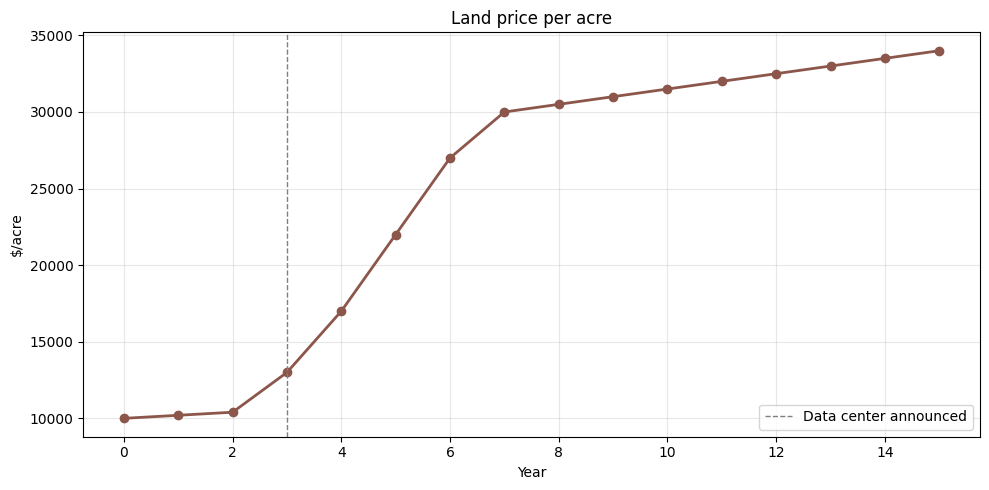

In [5]:
fig, ax = plt.subplots()
ax.plot(df['year'], df['land_per_acre'], marker='o', linewidth=2, color='#8c564b')
ax.axvline(3, color='gray', linestyle='--', linewidth=1, label='Data center announced')
ax.set_title('Land price per acre')
ax.set_xlabel('Year')
ax.set_ylabel('$/acre')
ax.legend()
plt.tight_layout()
plt.show()

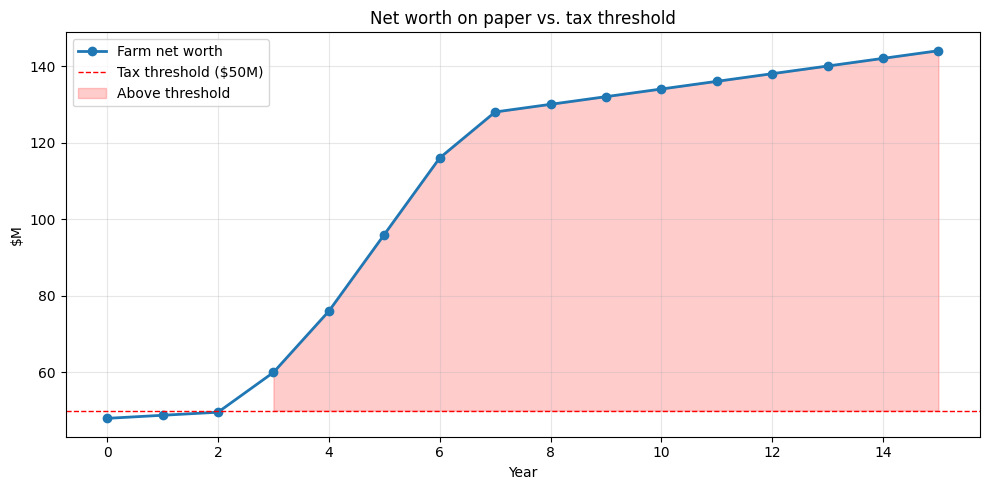

In [6]:
fig, ax = plt.subplots()
ax.plot(df['year'], df['net_worth']/1e6, marker='o', linewidth=2, color='#1f77b4', label='Farm net worth')
ax.axhline(wealth_threshold/1e6, color='red', linestyle='--', linewidth=1, label='Tax threshold ($50M)')
ax.fill_between(df['year'], wealth_threshold/1e6, df['net_worth']/1e6,
                where=df['above_threshold'], alpha=0.2, color='red',
                label='Above threshold')
ax.set_title('Net worth on paper vs. tax threshold')
ax.set_xlabel('Year')
ax.set_ylabel('$M')
ax.legend()
plt.tight_layout()
plt.show()

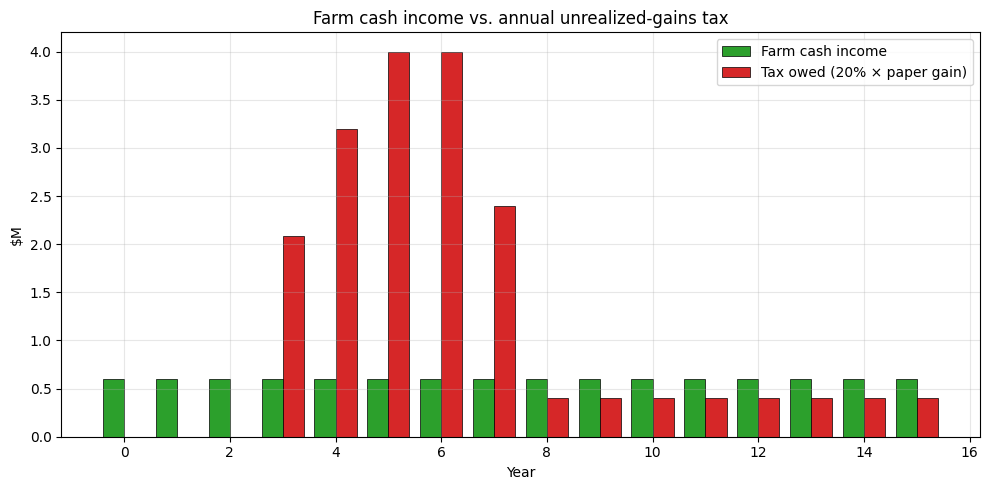

In [7]:
fig, ax = plt.subplots()
width = 0.4
ax.bar(df['year'] - width/2, df['farm_cash_income']/1e6, width,
       label='Farm cash income', color='#2ca02c', edgecolor='black', linewidth=0.5)
ax.bar(df['year'] + width/2, df['tax_owed']/1e6, width,
       label='Tax owed (20% × paper gain)', color='#d62728', edgecolor='black', linewidth=0.5)
ax.set_title('Farm cash income vs. annual unrealized-gains tax')
ax.set_xlabel('Year')
ax.set_ylabel('$M')
ax.legend()
plt.tight_layout()
plt.show()

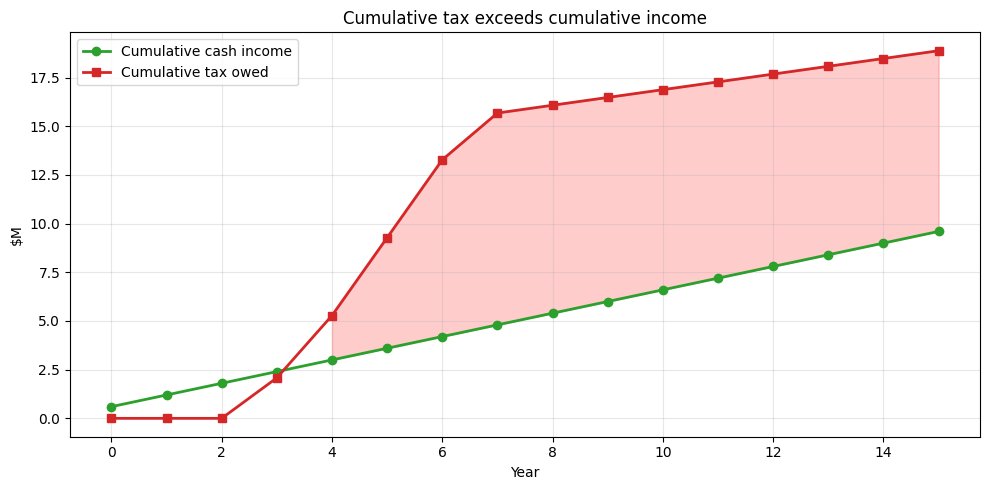

In [8]:
fig, ax = plt.subplots()
ax.plot(df['year'], df['cum_cash_income']/1e6, marker='o', linewidth=2,
        label='Cumulative cash income', color='#2ca02c')
ax.plot(df['year'], df['cum_tax']/1e6,         marker='s', linewidth=2,
        label='Cumulative tax owed',    color='#d62728')
ax.fill_between(df['year'], df['cum_cash_income']/1e6, df['cum_tax']/1e6,
                where=df['cum_tax'] > df['cum_cash_income'], alpha=0.2, color='red')
ax.set_title('Cumulative tax exceeds cumulative income')
ax.set_xlabel('Year')
ax.set_ylabel('$M')
ax.legend()
plt.tight_layout()
plt.show()

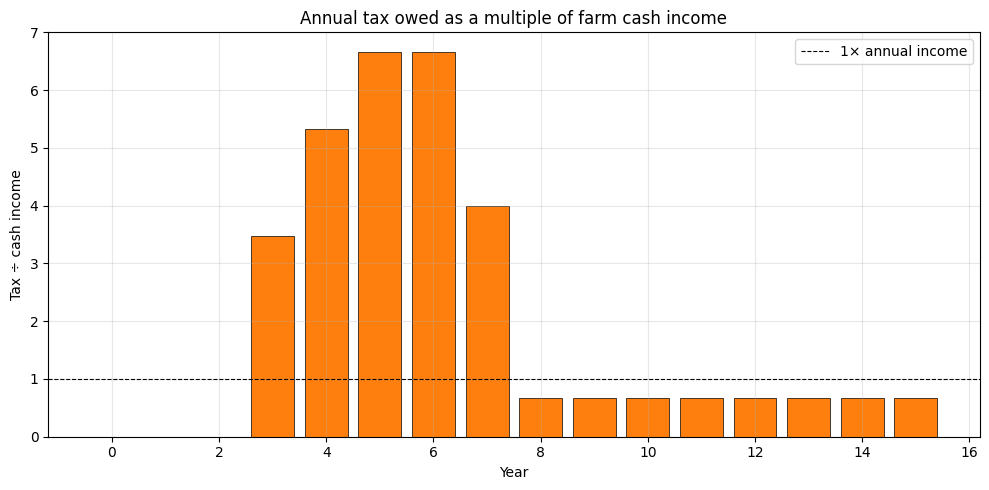

In [9]:
fig, ax = plt.subplots()
ratio = df['tax_owed'] / df['farm_cash_income']
ax.bar(df['year'], ratio, color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='1× annual income')
ax.set_title('Annual tax owed as a multiple of farm cash income')
ax.set_xlabel('Year')
ax.set_ylabel('Tax ÷ cash income')
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- The farm's *real* economic activity has not changed. The corn still pays roughly what corn pays. But the speculative bid-up of nearby parcels drags this farm's paper value across the threshold and forces a huge annual tax bill.
- During the price-shock years, the annual tax is a **multiple of the entire farm's cash income**. There is no way to pay it from operations.
- The only way to pay is to **sell off acres** — to the same kind of developer-funded buyer who created the shock in the first place. This means the policy effectively *accelerates* the conversion of family farmland into commercial use, which is plausibly the opposite of what its proponents want.
- The asymmetry matters too. If the data-center plan falls through in year 8 and land prices drop back to \$15k/acre, the farmer's prior tax payments are *not refunded*. She paid real cash for a paper gain that never materialized into anything she could spend.